# Clustering Trace: k-means (Euclidean vs DTW) and k-Shape

The [Trace](https://timeseriesclassification.com/description.php?Dataset=Trace) dataset simulates instrument failures in a nuclear power plant: 200 series of length 275 in 4 classes. The classes differ in the *shape* of a transient, and the transient starts at a different time in each series. This makes it a textbook case for shift-invariant distances.

This notebook drives the same package functions as `make pipeline`. The ground-truth labels are never shown to the models; they are only used to score the clusters.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment

from tsclustering.data.make_dataset import make_dataset
from tsclustering.features.build_features import build_features
from tsclustering.models.train_model import MODELS, train
from tsclustering.utils.paths import reports_figures_dir
from tsclustering.visualization.visualize import (
    MEMBER_GREY,
    PALETTE,
    plot_clusters,
    set_style,
)

set_style()

In [2]:
X_raw, y = make_dataset("Trace")
X = build_features(X_raw)
classes = np.unique(y)
X.shape

(200, 275, 1)

## Experiment 1: what do the classes look like?

Each panel shows every series of one class in grey, with the class mean in color.

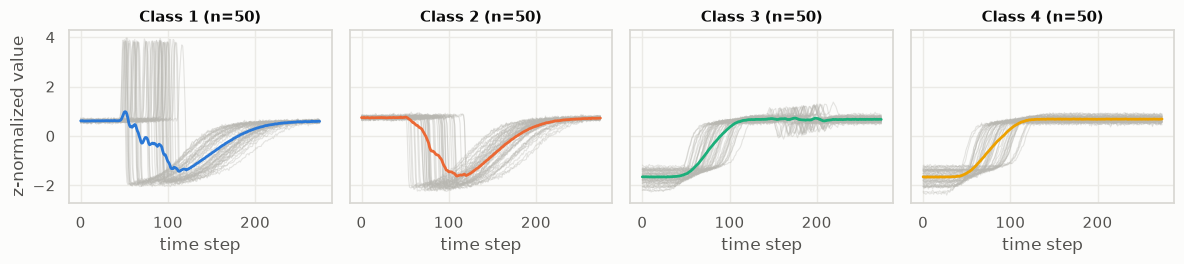

In [3]:
fig, axes = plt.subplots(1, len(classes), figsize=(12, 2.8), sharey=True)
for ax, k, color in zip(axes, classes, PALETTE):
    for series in X[y == k]:
        ax.plot(series.ravel(), color=MEMBER_GREY, alpha=0.35, lw=0.8)
    ax.plot(X[y == k].mean(axis=0).ravel(), color=color)
    ax.set_title(f"Class {k} (n={np.sum(y == k)})")
    ax.set_xlabel("time step")
axes[0].set_ylabel("z-normalized value")
fig.tight_layout()
fig.savefig(reports_figures_dir("trace_classes.png"), dpi=150, bbox_inches="tight")
plt.show()

The class means are smeared because the transients are not aligned in time. The classes come in two look-alike pairs: **1 vs 2** (a drop, with or without a short spike just before it) and **3 vs 4** (a rise, with or without a brief oscillation after it). A good clusterer has to pick up these small details while ignoring *when* the event happens.

## Experiment 2: which model recovers the classes best?

The three models are fit with `k = 4`, and each is scored with:
- **ARI** (adjusted Rand index): agreement with the true classes; 1 = perfect, 0 = random.
- **NMI** (normalized mutual information): how much the clusters tell you about the classes; 1 = perfect.
- **Silhouette**: how compact and separated the clusters are, in the model's own distance. It needs no labels.

In [4]:
results, models = {}, {}
for name in MODELS:
    models[name], results[name] = train(X, y, name)
results_df = pd.DataFrame(results).T[["ari", "nmi", "silhouette"]]
results_df.round(3)

,ari,nmi,silhouette
kmeans-euclidean,0.328,0.502,0.429
kmeans-dtw,0.664,0.753,0.677
kshape,0.661,0.817,0.387


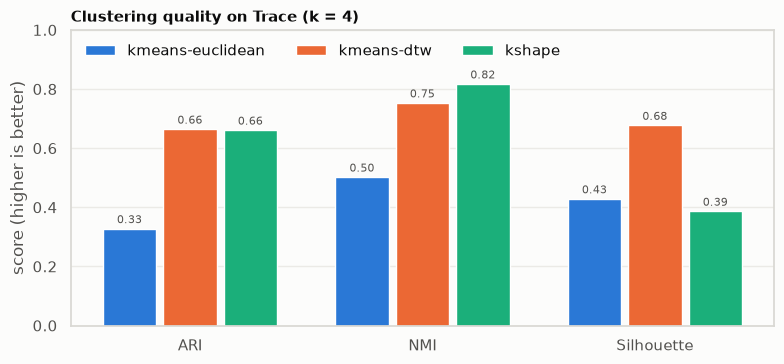

In [5]:
metrics = ["ari", "nmi", "silhouette"]
width = 0.26
fig, ax = plt.subplots(figsize=(8, 3.8))
for m, (name, color) in enumerate(zip(results_df.index, PALETTE)):
    xs = np.arange(len(metrics)) + (m - 1) * width
    bars = ax.bar(xs, results_df.loc[name, metrics], width - 0.03, color=color, label=name)
    ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=8, color="#52514e")
ax.set_xticks(np.arange(len(metrics)), ["ARI", "NMI", "Silhouette"])
ax.set_ylim(0, 1)
ax.set_ylabel("score (higher is better)")
ax.legend(frameon=False, ncols=3, loc="upper left")
ax.grid(axis="x", visible=False)
ax.set_title("Clustering quality on Trace (k = 4)", loc="left")
fig.tight_layout()
fig.savefig(reports_figures_dir("model_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

Allowing the time axis to warp (DTW) or comparing shapes up to a shift (k-Shape) doubles the ARI over plain Euclidean k-means. The DTW silhouette is measured in DTW distance, so it is not comparable with the two Euclidean ones.

## Experiment 3: what did each model find?

Each row is one model and each column one cluster. The members are grey and the cluster center is in color: a DBA barycenter for DTW, a centroid for the others.

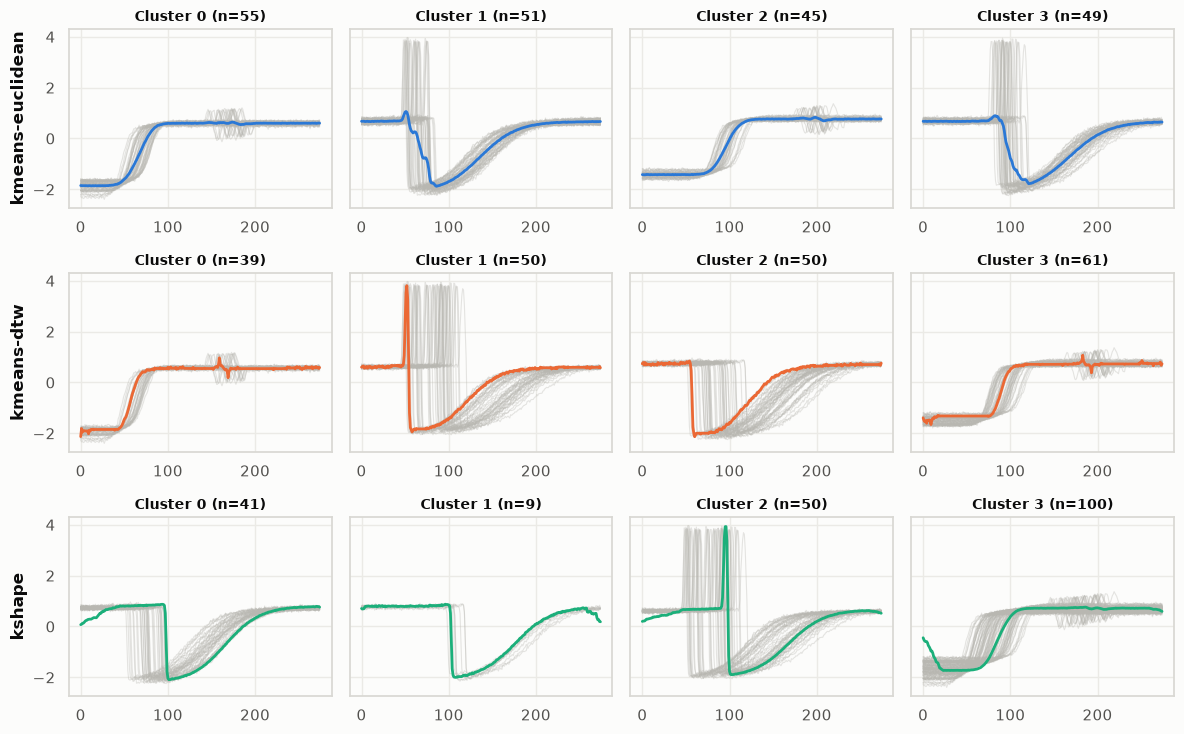

In [6]:
fig, axes = plt.subplots(len(models), 4, figsize=(12, 2.5 * len(models)), sharey=True)
for row, (name, model), color in zip(axes, models.items(), PALETTE):
    plot_clusters(X, model.labels_, model.cluster_centers_, color=color, axes=row)
    row[0].set_ylabel(name, fontweight="bold", color="#0b0b0b")
fig.tight_layout()
fig.savefig(reports_figures_dir("clusters_grid.png"), dpi=150, bbox_inches="tight")
plt.show()

- **Euclidean** groups series by *when* the transient happens: early drops, late drops, early rises, late rises. Its centroids are blurry averages.
- **DTW** gets clean drop clusters, with and without the spike, and its barycenters keep sharp edges, because each series is aligned before averaging. The rises are still split by timing.
- **k-Shape** merges the two rise classes into one cluster of 100 and splits the drops into uneven groups.

## Experiment 4: where do the models go wrong?

This contingency table shows the true classes (rows) against the clusters (columns). The clusters are reordered to best match the classes, so a perfect result is a diagonal.

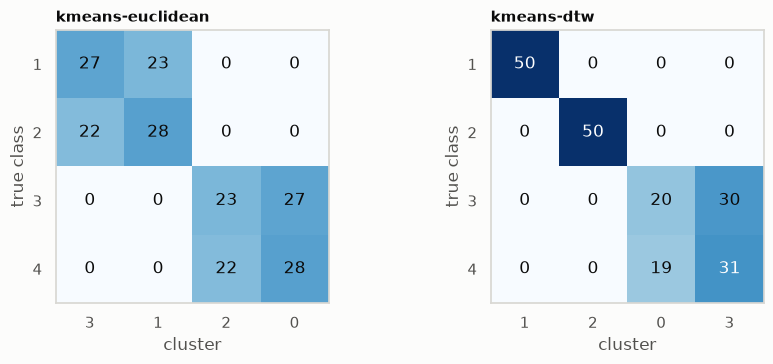

In [7]:
def matched_crosstab(labels):
    table = pd.crosstab(pd.Series(y, name="true class"), pd.Series(labels, name="cluster"))
    _, cols = linear_sum_assignment(-table.to_numpy())
    return table.iloc[:, cols]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, name in zip(axes, ["kmeans-euclidean", "kmeans-dtw"]):
    table = matched_crosstab(models[name].labels_)
    ax.imshow(table, cmap="Blues", vmin=0, vmax=50)
    for (i, j), v in np.ndenumerate(table.to_numpy()):
        ax.text(j, i, v, ha="center", va="center", color="white" if v > 30 else "#0b0b0b")
    ax.set_xticks(range(4), table.columns)
    ax.set_yticks(range(4), table.index)
    ax.set_xlabel("cluster")
    ax.set_ylabel("true class")
    ax.set_title(name, loc="left")
    ax.grid(False)
fig.tight_layout()
fig.savefig(reports_figures_dir("contingency.png"), dpi=150, bbox_inches="tight")
plt.show()

Euclidean k-means never mixes drops with rises, but inside each pair it splits roughly 50/50: it is clustering by timing, not by class. DTW fixes classes 1 and 2 completely (50/50 on the diagonal), but the small oscillation separating classes 3 and 4 is too weak a signal. DTW still splits them by timing. Candidates to fix it are a constrained DTW window, derivative DTW (which amplifies small wiggles), or more clusters followed by merging (see ROADMAP.md).